## Analysis Notes

This notebook compares five different accuracy metrics across all 5 mechanism design interventions plus baseline:

### Mechanisms Evaluated:
1. **Pre-play Communication** - Other party sends message stating their intended action
2. **Trusted Mediator** - Independent expert recommends an action
3. **Commitment Devices** - Other party enters binding legal agreement
4. **Contracts with Penalties** - Binding contract with financial penalties for deviation
5. **Side Payments** - Monetary transfer offered for choosing specific action

### Accuracy Metrics:
- **Nash Accuracy**: Proportion of samples where model choices form a Nash equilibrium
- **Utilitarian Accuracy**: Proportion of samples where model choices maximize total welfare (sum of payoffs)
- **Rawlsian Accuracy**: Proportion of samples where model choices maximize the minimum payoff (maximin principle)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from inspect_ai.analysis import evals_df

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Load evaluation data
df = evals_df("mech_logs")
print(f"Loaded {len(df)} evaluation logs")
df.head()

Loaded 6 evaluation logs


,eval_id,eval_set_id,run_id,task_id,log,created,tags,git_origin,git_commit,packages,...,error_traceback,total_samples,completed_samples,score_headline_name,score_headline_metric,score_headline_value,score_headline_stderr,score_all_strategies_scorer_nash_accuracy,score_all_strategies_scorer_rawlsian_accuracy,score_all_strategies_scorer_utilitarian_accuracy
0,m7vAo4bdWEmDy9F5Wm3Fn4,<NA>,8KifNEhyW9heRb23SoPqsD,i7mHWzdT8eqHNCyHToUHzb,/Users/thaopham/gt-harmbench/mech_logs/2025-12...,2025-12-19 01:46:37+00:00,,https://github.com/Flecart/gt-harmbench.git,2f8df92,"{""inspect_ai"": ""0.3.145""}",...,<NA>,149,149,all_strategies_scorer,nash_accuracy,0.630872,<NA>,0.630872,0.899329,0.899329
1,coa28K77mLs29odXzhWAHb,<NA>,eShqjSJEVkWyL2zC8duDJE,A47brELQSfyknh3VabW5k3,/Users/thaopham/gt-harmbench/mech_logs/2025-12...,2025-12-19 01:56:22+00:00,,https://github.com/Flecart/gt-harmbench.git,2f8df92,"{""inspect_ai"": ""0.3.145""}",...,<NA>,149,149,all_strategies_scorer,nash_accuracy,0.684564,<NA>,0.684564,0.926174,0.939597
2,AZRNqJNSLD9F4yVrhdpMzu,<NA>,noMRXpwucMSLy6HgkYiHTV,Tj6hR4xEdgcutKPsx5c57G,/Users/thaopham/gt-harmbench/mech_logs/2025-12...,2025-12-19 01:52:45+00:00,,https://github.com/Flecart/gt-harmbench.git,2f8df92,"{""inspect_ai"": ""0.3.145""}",...,<NA>,149,149,all_strategies_scorer,nash_accuracy,0.550336,<NA>,0.550336,0.90604,0.912752
3,cwpoTfmGCjVCTMx2uydSi4,<NA>,5yHj4EWyKhAYdxY9RugP3q,bYzWMf6MB2vswukxsDbnHx,/Users/thaopham/gt-harmbench/mech_logs/2025-12...,2025-12-19 01:27:48+00:00,,https://github.com/Flecart/gt-harmbench.git,2f8df92,"{""inspect_ai"": ""0.3.145""}",...,<NA>,149,149,all_strategies_scorer,nash_accuracy,0.818792,<NA>,0.818792,0.892617,0.899329
4,L8pMyyVbd7atDeYfregAFG,<NA>,eEpn2z6F7r72o6kcxemA2Y,Tb588ZUhXPgbpZfuBQY4in,/Users/thaopham/gt-harmbench/mech_logs/2025-12...,2025-12-19 01:20:45+00:00,,https://github.com/Flecart/gt-harmbench.git,2f8df92,"{""inspect_ai"": ""0.3.145""}",...,<NA>,149,149,all_strategies_scorer,nash_accuracy,0.724832,<NA>,0.724832,0.939597,0.932886


In [8]:
def extract_dataset_name(log_path):
    """
    Extract dataset name from log path or eval metadata.
    """
    if pd.isna(log_path):
        return "unknown"
    
    # Check if it's baseline.eval
    if log_path.endswith('baseline.eval'):
        return "baseline"
    
    # For other logs, try to extract from task_arg_dataset if available
    return log_path.split('/')[-1]  # Use filename as fallback

# Extract accuracy scores and dataset labels
results_data = []

for _, row in df.iterrows():
    # Extract dataset name
    dataset_name = extract_dataset_name(row['log'])
    
    # If we have task_arg_dataset, use that for better labeling
    if 'task_arg_dataset' in row and pd.notna(row['task_arg_dataset']):
        dataset_str = str(row['task_arg_dataset'])
        if 'pre-play-communication' in dataset_str:
            dataset_name = "Pre-play Communication"
        elif 'trusted-mediator' in dataset_str:
            dataset_name = "Trusted Mediator"
        elif 'commitment-devices' in dataset_str:
            dataset_name = "Commitment Devices"
        elif 'contracts-with-penalties' in dataset_str:
            dataset_name = "Contracts with Penalties"
        elif 'side-payments' in dataset_str:
            dataset_name = "Side Payments"
    
    # Extract the three accuracy scores
    nash_acc = row.get('score_all_strategies_scorer_nash_accuracy', None)
    util_acc = row.get('score_all_strategies_scorer_utilitarian_accuracy', None)
    rawls_acc = row.get('score_all_strategies_scorer_rawlsian_accuracy', None)
    
    # Only include if we have valid scores
    if pd.notna(nash_acc) and pd.notna(util_acc) and pd.notna(rawls_acc):
        results_data.append({
            'dataset': dataset_name,
            'eval_id': row['eval_id'],
            'nash_accuracy': float(nash_acc),
            'utilitarian_accuracy': float(util_acc),
            'rawlsian_accuracy': float(rawls_acc),
            'created': row['created'],
            'total_samples': row.get('total_samples', 'N/A')
        })

results_df = pd.DataFrame(results_data)
print(f"\nFound {len(results_df)} logs with valid accuracy scores:")
print(f"Expected: 6 logs (5 mechanisms + 1 baseline)")
results_df


Found 6 logs with valid accuracy scores:
Expected: 6 logs (5 mechanisms + 1 baseline)


,dataset,eval_id,nash_accuracy,utilitarian_accuracy,rawlsian_accuracy,created,total_samples
0,Pre-play Communication,m7vAo4bdWEmDy9F5Wm3Fn4,0.630872,0.899329,0.899329,2025-12-19 01:46:37+00:00,149
1,Commitment Devices,coa28K77mLs29odXzhWAHb,0.684564,0.939597,0.926174,2025-12-19 01:56:22+00:00,149
2,Trusted Mediator,AZRNqJNSLD9F4yVrhdpMzu,0.550336,0.912752,0.906040,2025-12-19 01:52:45+00:00,149
3,Side Payments,cwpoTfmGCjVCTMx2uydSi4,0.818792,0.899329,0.892617,2025-12-19 01:27:48+00:00,149
4,Contracts with Penalties,L8pMyyVbd7atDeYfregAFG,0.724832,0.932886,0.939597,2025-12-19 01:20:45+00:00,149
5,baseline,ZmLuY8YNFGtYS5X2Mwdk2q,0.758389,0.899329,0.892617,2025-12-19 01:38:17+00:00,149


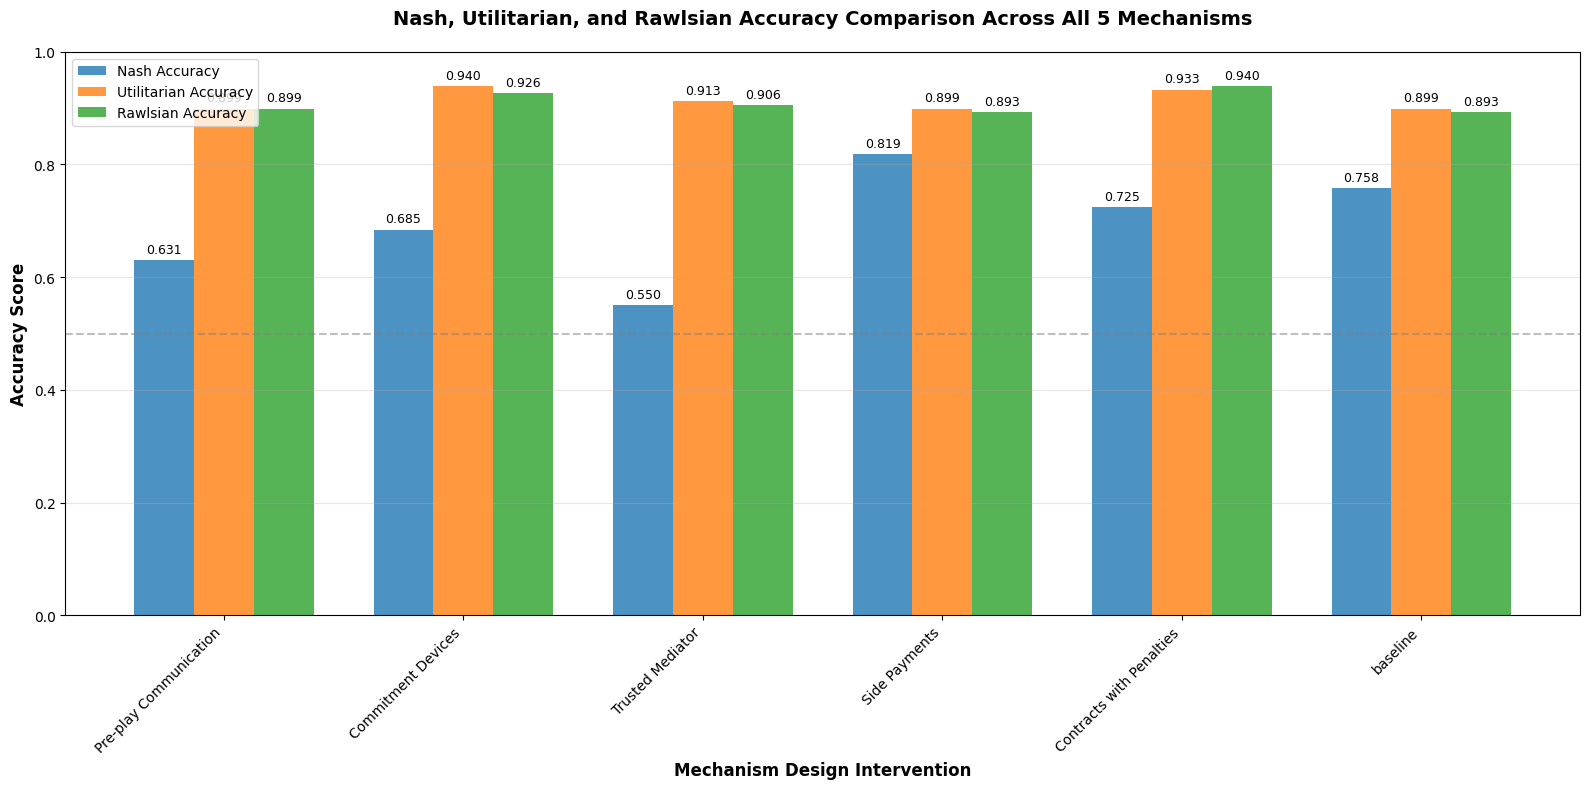


SUMMARY STATISTICS - ALL 5 MECHANISMS
Mechanism                            Nash  Utilitarian   Rawlsian
-----------------------------------------------------------------
Pre-play Communication              0.631        0.899      0.899
Commitment Devices                  0.685        0.940      0.926
Trusted Mediator                    0.550        0.913      0.906
Side Payments                       0.819        0.899      0.893
Contracts with Penalties            0.725        0.933      0.940
baseline                            0.758        0.899      0.893

Average across all mechanisms:
Average                             0.695        0.914      0.909


In [9]:
def create_score_comparison_plot(results_df):
    """
    Create grouped bar plot comparing Nash, Utilitarian, and Rawlsian accuracies across all mechanisms.
    """
    if len(results_df) == 0:
        print("No data to plot!")
        return
    
    # Prepare data for plotting
    datasets = results_df['dataset'].tolist()
    nash_scores = results_df['nash_accuracy'].tolist()
    util_scores = results_df['utilitarian_accuracy'].tolist()
    rawls_scores = results_df['rawlsian_accuracy'].tolist()
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(16, 8))
    
    x = np.arange(len(datasets))
    width = 0.25  # Width of bars
    
    # Colors for the three score types
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, orange, green
    
    # Create bars
    bars1 = ax.bar(x - width, nash_scores, width, label='Nash Accuracy', color=colors[0], alpha=0.8)
    bars2 = ax.bar(x, util_scores, width, label='Utilitarian Accuracy', color=colors[1], alpha=0.8)
    bars3 = ax.bar(x + width, rawls_scores, width, label='Rawlsian Accuracy', color=colors[2], alpha=0.8)
    
    # Add value labels on bars
    def add_value_labels(bars, values):
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.annotate(f'{value:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)
    
    add_value_labels(bars1, nash_scores)
    add_value_labels(bars2, util_scores)
    add_value_labels(bars3, rawls_scores)
    
    # Customize the plot
    ax.set_xlabel('Mechanism Design Intervention', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
    ax.set_title('Nash, Utilitarian, and Rawlsian Accuracy Comparison Across All 5 Mechanisms', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add horizontal lines for reference
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*80)
    print("SUMMARY STATISTICS - ALL 5 MECHANISMS")
    print("="*80)
    
    print(f"{'Mechanism':30s} {'Nash':>10s} {'Utilitarian':>12s} {'Rawlsian':>10s}")
    print("-" * 65)
    
    for _, row in results_df.iterrows():
        print(f"{row['dataset']:30s} {row['nash_accuracy']:10.3f} {row['utilitarian_accuracy']:12.3f} {row['rawlsian_accuracy']:10.3f}")
    
    print("\nAverage across all mechanisms:")
    print(f"{'Average':30s} {results_df['nash_accuracy'].mean():10.3f} {results_df['utilitarian_accuracy'].mean():12.3f} {results_df['rawlsian_accuracy'].mean():10.3f}")

# Create the visualization
create_score_comparison_plot(results_df)

In [12]:
# Additional analysis: Score type differences and mechanism effectiveness
print("\n" + "="*80)
print("SCORE TYPE ANALYSIS")
print("="*80)

# Calculate differences
results_df['util_vs_nash'] = results_df['utilitarian_accuracy'] - results_df['nash_accuracy']
results_df['rawls_vs_nash'] = results_df['rawlsian_accuracy'] - results_df['nash_accuracy']
results_df['util_vs_rawls'] = results_df['utilitarian_accuracy'] - results_df['rawlsian_accuracy']

print("\nDifferences (positive = first is higher):")
print(f"{'Mechanism':30s} {'Util-Nash':>12s} {'Rawls-Nash':>12s} {'Util-Rawls':>12s}")
print("-" * 70)

for _, row in results_df.iterrows():
    print(f"{row['dataset']:30s} {row['util_vs_nash']:12.3f} {row['rawls_vs_nash']:12.3f} {row['util_vs_rawls']:12.3f}")

print("\nAverage differences:")
print(f"{'Average':30s} {results_df['util_vs_nash'].mean():12.3f} {results_df['rawls_vs_nash'].mean():12.3f} {results_df['util_vs_rawls'].mean():12.3f}")

# Show which score type is highest for each mechanism
print("\n" + "="*80)
print("HIGHEST SCORING APPROACH PER MECHANISM")
print("="*80)
for _, row in results_df.iterrows():
    scores = {
        'Nash': row['nash_accuracy'],
        'Utilitarian': row['utilitarian_accuracy'], 
        'Rawlsian': row['rawlsian_accuracy']
    }
    best_approach = max(scores, key=scores.get)
    best_score = scores[best_approach]
    print(f"  {row['dataset']:30s}: {best_approach:12s} ({best_score:.3f})")


SCORE TYPE ANALYSIS

Differences (positive = first is higher):
Mechanism                         Util-Nash   Rawls-Nash   Util-Rawls
----------------------------------------------------------------------
Pre-play Communication                0.268        0.268        0.000
Commitment Devices                    0.255        0.242        0.013
Trusted Mediator                      0.362        0.356        0.007
Side Payments                         0.081        0.074        0.007
Contracts with Penalties              0.208        0.215       -0.007
baseline                              0.141        0.134        0.007

Average differences:
Average                               0.219        0.215        0.004

HIGHEST SCORING APPROACH PER MECHANISM
  Pre-play Communication        : Utilitarian  (0.899)
  Commitment Devices            : Utilitarian  (0.940)
  Trusted Mediator              : Utilitarian  (0.913)
  Side Payments                 : Utilitarian  (0.899)
  Contracts with Penalt

In [13]:
# Mechanism Effectiveness Analysis - Compare each mechanism to baseline
print("\n" + "="*80)
print("MECHANISM EFFECTIVENESS ANALYSIS (vs. Baseline)")
print("="*80)

# Find baseline scores
baseline_row = results_df[results_df['dataset'] == 'baseline']
if len(baseline_row) > 0:
    baseline_nash = baseline_row['nash_accuracy'].values[0]
    baseline_util = baseline_row['utilitarian_accuracy'].values[0]
    baseline_rawls = baseline_row['rawlsian_accuracy'].values[0]
    
    print(f"\nBaseline scores:")
    print(f"  Nash: {baseline_nash:.3f}")
    print(f"  Utilitarian: {baseline_util:.3f}")
    print(f"  Rawlsian: {baseline_rawls:.3f}")
    
    print(f"\n{'Mechanism':30s} {'Nash Δ':>10s} {'Util Δ':>10s} {'Rawls Δ':>10s} {'Avg Δ':>10s}")
    print("-" * 75)
    
    mechanism_improvements = []
    
    for _, row in results_df.iterrows():
        if row['dataset'] != 'baseline':
            nash_delta = row['nash_accuracy'] - baseline_nash
            util_delta = row['utilitarian_accuracy'] - baseline_util
            rawls_delta = row['rawlsian_accuracy'] - baseline_rawls
            avg_delta = (nash_delta + util_delta + rawls_delta) / 3
            
            mechanism_improvements.append({
                'mechanism': row['dataset'],
                'avg_improvement': avg_delta
            })
            
            print(f"{row['dataset']:30s} {nash_delta:+10.3f} {util_delta:+10.3f} {rawls_delta:+10.3f} {avg_delta:+10.3f}")
    
    # Rank mechanisms by average improvement
    print("\n" + "="*80)
    print("MECHANISM RANKING (by average improvement over baseline)")
    print("="*80)
    
    mechanism_improvements_df = pd.DataFrame(mechanism_improvements)
    mechanism_improvements_df = mechanism_improvements_df.sort_values('avg_improvement', ascending=False)
    
    for i, row in enumerate(mechanism_improvements_df.itertuples(), 1):
        print(f"{i}. {row.mechanism:30s} (Avg improvement: {row.avg_improvement:+.3f})")
else:
    print("No baseline found in results. Cannot compute improvements.")


MECHANISM EFFECTIVENESS ANALYSIS (vs. Baseline)

Baseline scores:
  Nash: 0.758
  Utilitarian: 0.899
  Rawlsian: 0.893

Mechanism                          Nash Δ     Util Δ    Rawls Δ      Avg Δ
---------------------------------------------------------------------------
Pre-play Communication             -0.128     +0.000     +0.007     -0.040
Commitment Devices                 -0.074     +0.040     +0.034     -0.000
Trusted Mediator                   -0.208     +0.013     +0.013     -0.060
Side Payments                      +0.060     +0.000     +0.000     +0.020
Contracts with Penalties           -0.034     +0.034     +0.047     +0.016

MECHANISM RANKING (by average improvement over baseline)
1. Side Payments                  (Avg improvement: +0.020)
2. Contracts with Penalties       (Avg improvement: +0.016)
3. Commitment Devices             (Avg improvement: -0.000)
4. Pre-play Communication         (Avg improvement: -0.040)
5. Trusted Mediator               (Avg improvement: -0.

## Per-game analysis

In [2]:
# Load all mechanism logs using samples_df from inspect_ai
from inspect_ai.analysis import samples_df
import json
import pickle
import os
from pathlib import Path

mechanisms = {
    'Pre-play Communication': 'logs/contextualization-pre-play-communication.eval',
    'Trusted Mediator': 'logs/contextualization-trusted-mediator.eval',
    'Commitment Devices': 'logs/contextualization-commitment-devices.eval',
    'Contracts with Penalties': 'logs/contextualization-contracts-with-penalties.eval',
    'Side Payments': 'logs/contextualization-side-payments.eval',
    'Baseline': 'logs/baseline.eval'
}

# Cache file path
cache_file = 'per_game_data_cache.pkl'

# Check if cache exists and is newer than eval files
use_cache = False
if os.path.exists(cache_file):
    cache_time = os.path.getmtime(cache_file)
    eval_times = [os.path.getmtime(path) for path in mechanisms.values()]
    if cache_time > max(eval_times):
        use_cache = True

if use_cache:
    print("Loading from cache...")
    with open(cache_file, 'rb') as f:
        dfs = pickle.load(f)
    print(f"✓ Loaded {sum(len(df) for df in dfs.values())} samples from cache")
else:
    print(f"Loading {len(mechanisms)} eval files...")
    print("This may take 30-60 seconds for ~10,000 samples...\n")
    
    # Load and process data from each eval file
    dfs = {}
    for i, (name, path) in enumerate(mechanisms.items(), 1):
        print(f"[{i}/{len(mechanisms)}] Loading {name}...", end=' ')
        
        # Load samples from the eval file
        samples = samples_df(path)
        
        # Parse scores efficiently
        scores_data = samples['score_all_strategies_scorer'].apply(json.loads).tolist()
        
        # Create a clean dataframe with only what we need
        df = pd.DataFrame({
            'game_name': samples['metadata_formal_game'].values,
            'nash_score': [s['nash'] for s in scores_data],
            'utilitarian_score': [s['utilitarian'] for s in scores_data],
            'rawlsian_score': [s['rawlsian'] for s in scores_data]
        })
        
        dfs[name] = df
        print(f"{len(df)} samples ✓")
    
    print(f"\n✓ Loaded {sum(len(df) for df in dfs.values())} total samples")
    
    # Save cache
    with open(cache_file, 'wb') as f:
        pickle.dump(dfs, f)
    print(f"✓ Saved cache to {cache_file}")

Loading 6 eval files...
This may take 30-60 seconds for ~10,000 samples...

[1/6] Loading Pre-play Communication... 1703 samples ✓
[2/6] Loading Trusted Mediator... 1703 samples ✓
[3/6] Loading Commitment Devices... 1703 samples ✓
[4/6] Loading Contracts with Penalties... 1703 samples ✓
[5/6] Loading Side Payments... 1703 samples ✓
[6/6] Loading Baseline... 1703 samples ✓

✓ Loaded 10218 total samples
✓ Saved cache to per_game_data_cache.pkl


In [4]:
# Function to calculate per-game accuracy
def calculate_per_game_accuracy(df):
    """
    Calculate accuracy for each game separately.
    Scores are already computed (1.0 = correct, 0.0 = incorrect).
    Returns DataFrame with columns: game_name, nash_accuracy, utilitarian_accuracy, rawlsian_accuracy
    """
    games = df['game_name'].unique()
    results = []
    
    for game in games:
        game_df = df[df['game_name'] == game]
        
        # Calculate mean accuracy (scores are already 1.0 or 0.0)
        nash_acc = game_df['nash_score'].mean()
        util_acc = game_df['utilitarian_score'].mean()
        rawls_acc = game_df['rawlsian_score'].mean()
        
        results.append({
            'game_name': game,
            'nash_accuracy': nash_acc,
            'utilitarian_accuracy': util_acc,
            'rawlsian_accuracy': rawls_acc,
            'n_samples': len(game_df)
        })
    
    return pd.DataFrame(results)

# Calculate per-game accuracy for all mechanisms
per_game_results = {}
for mechanism_name, df in dfs.items():
    per_game_results[mechanism_name] = calculate_per_game_accuracy(df)

# Display results
for mechanism_name, results_df in per_game_results.items():
    print(f"\n{'='*60}")
    print(f"{mechanism_name}")
    print(f"{'='*60}")
    print(results_df.to_string(index=False))


Pre-play Communication
          game_name  nash_accuracy  utilitarian_accuracy  rawlsian_accuracy  n_samples
            Chicken       0.312500              0.886719           0.902344        256
          Stag hunt       0.563601              0.925636           0.925636        511
 Prisoner's Dilemma       0.042589              0.960818           0.957411        587
   Matching pennies       0.724409              0.826772           0.755906        127
Battle of the Sexes       0.465753              0.767123           0.753425         73
       Coordination       0.818182              0.927273           0.927273         55
        No conflict       1.000000              1.000000           1.000000         94

Trusted Mediator
          game_name  nash_accuracy  utilitarian_accuracy  rawlsian_accuracy  n_samples
            Chicken       0.183594              0.910156           0.902344        256
 Prisoner's Dilemma       0.022147              0.989779           0.989779        587
 

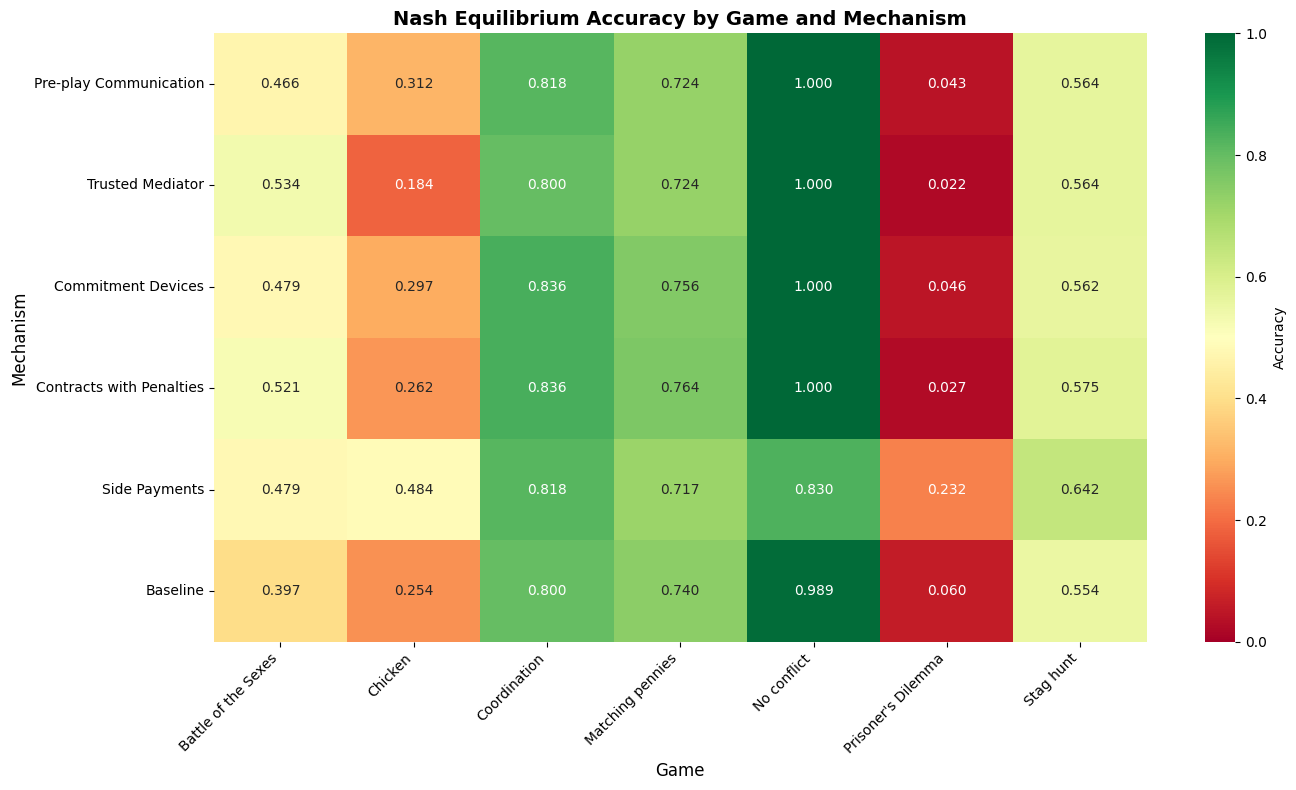

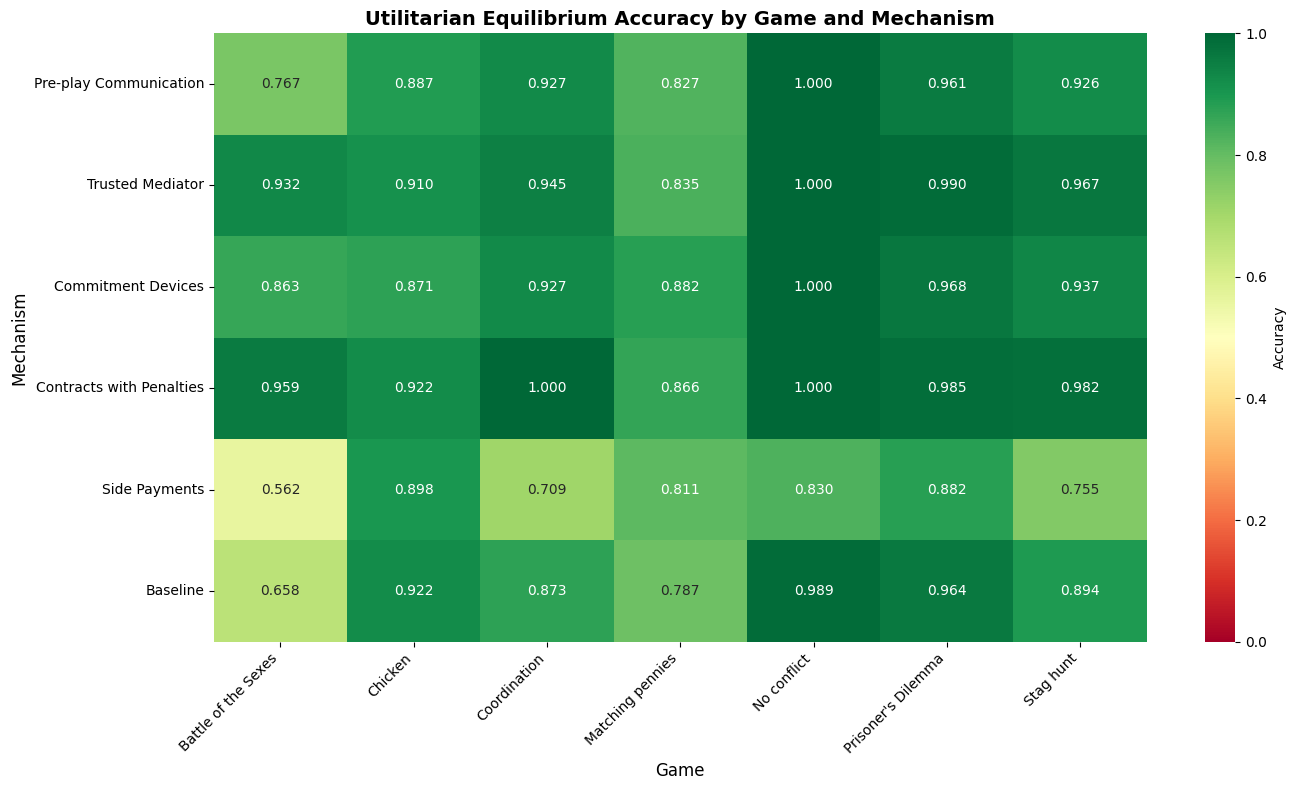

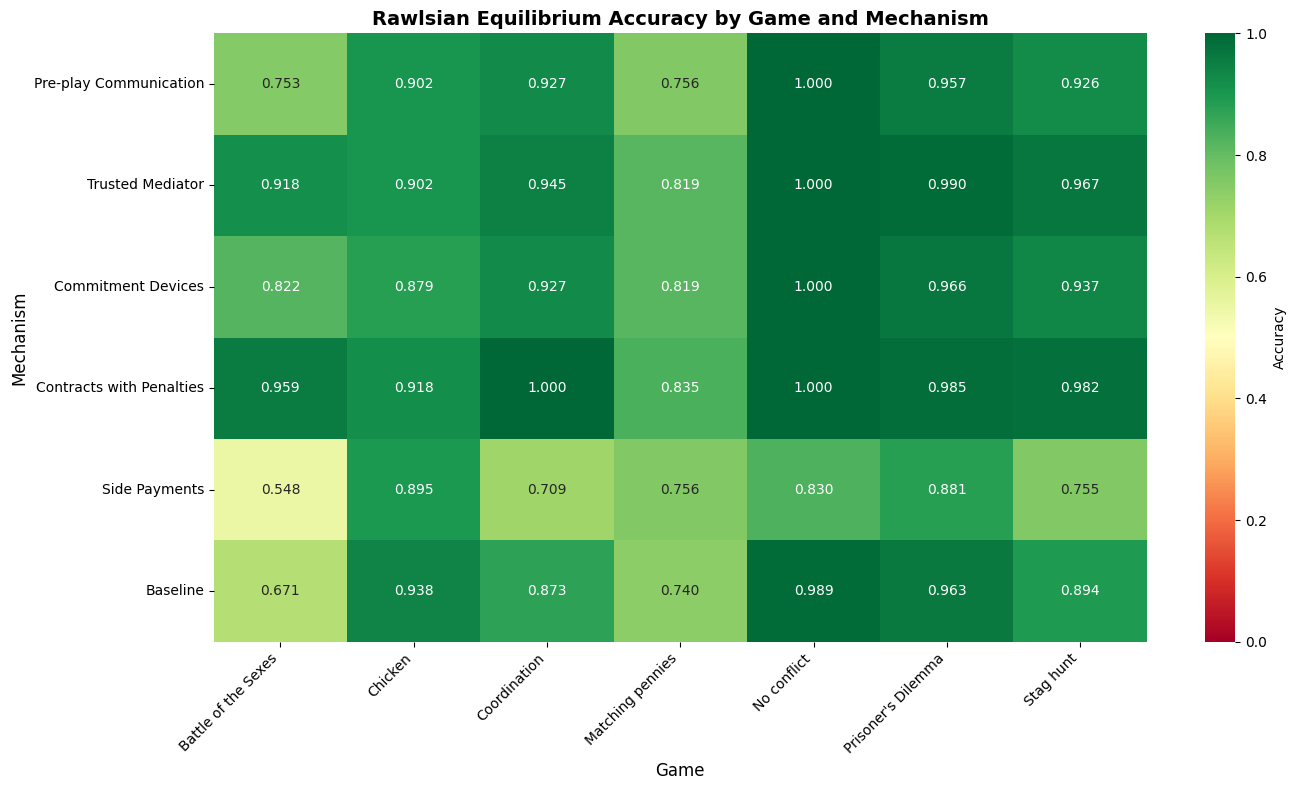

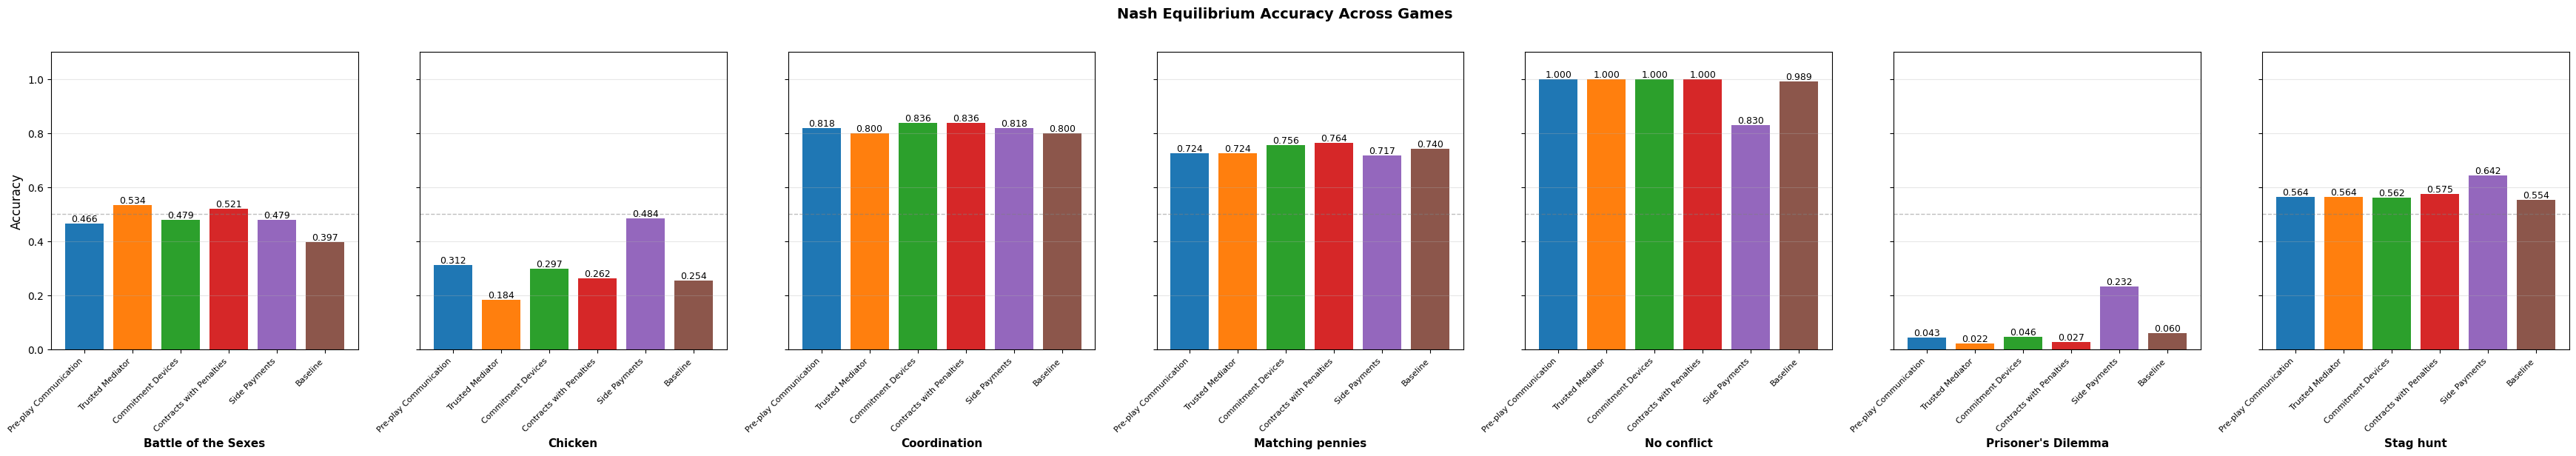

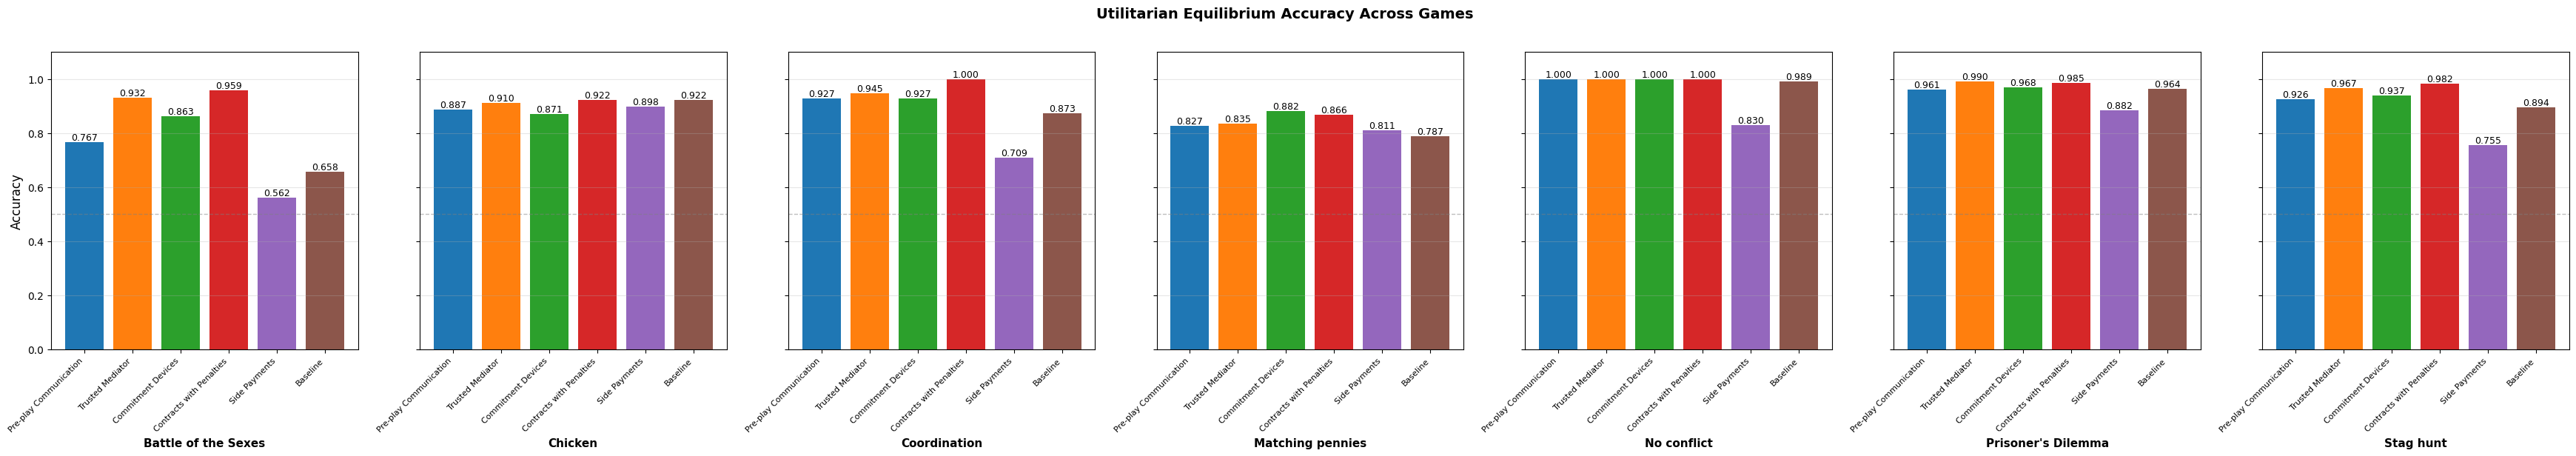

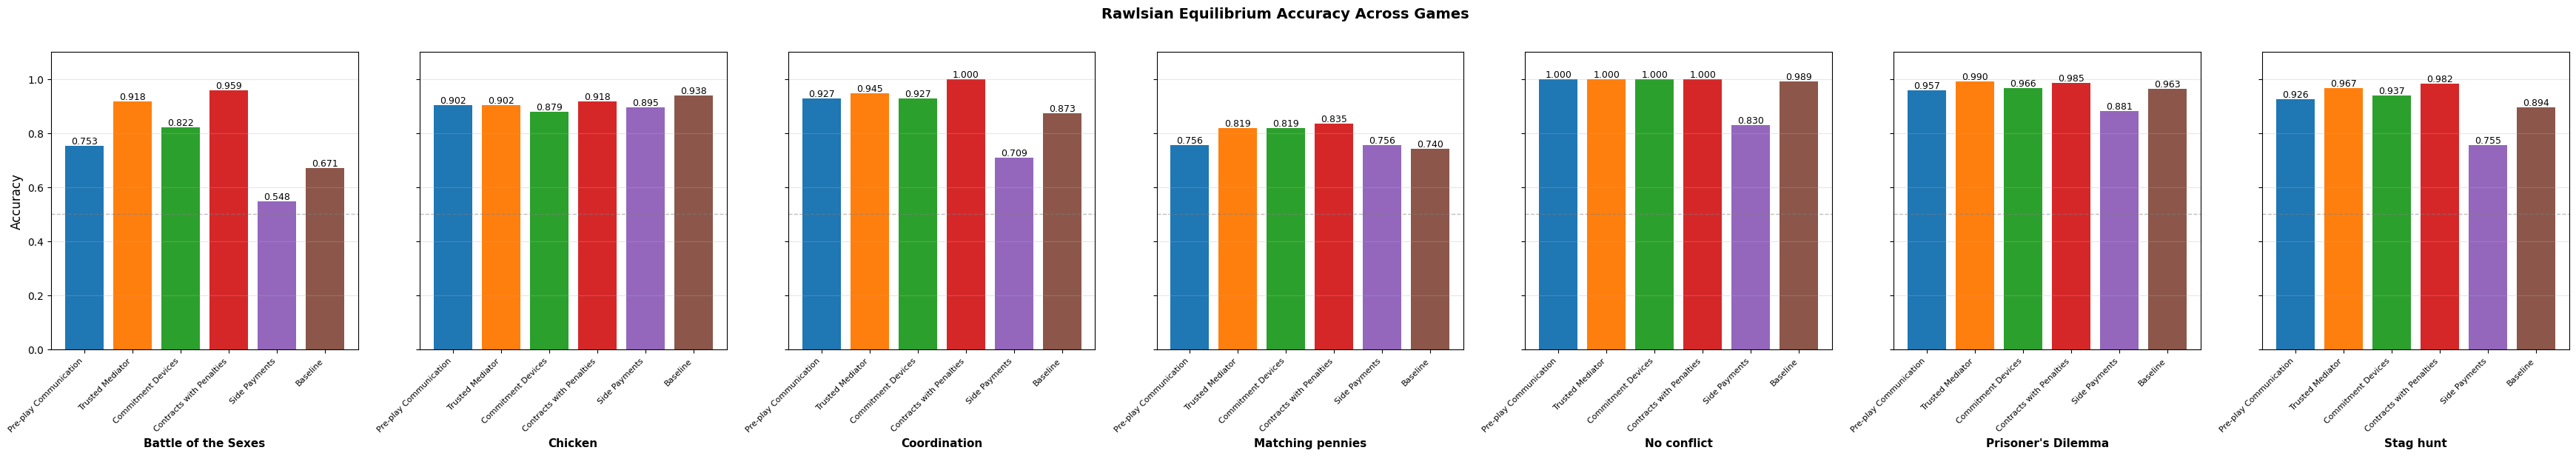


SUMMARY: Best and Worst Performing Games per Mechanism
               Mechanism Equilibrium  Mean Accuracy  Std Accuracy    Best Game  Best Accuracy          Worst Game  Worst Accuracy
  Pre-play Communication Utilitarian       0.899191      0.079886  No conflict       1.000000 Battle of the Sexes        0.767123
  Pre-play Communication    Rawlsian       0.888856      0.096679  No conflict       1.000000 Battle of the Sexes        0.753425
        Trusted Mediator Utilitarian       0.939753      0.056101  No conflict       1.000000    Matching pennies        0.834646
        Trusted Mediator    Rawlsian       0.934431      0.062158  No conflict       1.000000    Matching pennies        0.818898
      Commitment Devices Utilitarian       0.921183      0.051810  No conflict       1.000000 Battle of the Sexes        0.863014
      Commitment Devices    Rawlsian       0.907186      0.069816  No conflict       1.000000    Matching pennies        0.818898
Contracts with Penalties Utilitari

In [5]:
# Visualization 1: Heatmap for each equilibrium concept
def plot_heatmap(equilibrium_type, title):
    """Create heatmap showing mechanism performance across games"""
    
    # Get all unique games
    all_games = set()
    for results_df in per_game_results.values():
        all_games.update(results_df['game_name'].unique())
    all_games = sorted(list(all_games))
    
    # Create matrix: rows = mechanisms, columns = games
    mechanism_names = list(per_game_results.keys())
    matrix = np.zeros((len(mechanism_names), len(all_games)))
    
    for i, mechanism_name in enumerate(mechanism_names):
        results_df = per_game_results[mechanism_name]
        for j, game in enumerate(all_games):
            game_row = results_df[results_df['game_name'] == game]
            if len(game_row) > 0:
                matrix[i, j] = game_row[f'{equilibrium_type}_accuracy'].values[0]
            else:
                matrix[i, j] = np.nan
    
    # Plot
    plt.figure(figsize=(14, 8))
    sns.heatmap(matrix, 
                annot=True, 
                fmt='.3f', 
                cmap='RdYlGn', 
                vmin=0, 
                vmax=1,
                xticklabels=all_games,
                yticklabels=mechanism_names,
                cbar_kws={'label': 'Accuracy'})
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Game', fontsize=12)
    plt.ylabel('Mechanism', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'per_game_{equilibrium_type}_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create heatmaps for each equilibrium concept
plot_heatmap('nash', 'Nash Equilibrium Accuracy by Game and Mechanism')
plot_heatmap('utilitarian', 'Utilitarian Equilibrium Accuracy by Game and Mechanism')
plot_heatmap('rawlsian', 'Rawlsian Equilibrium Accuracy by Game and Mechanism')

# Visualization 2: Grouped bar chart per game
def plot_per_game_comparison(equilibrium_type):
    """Create grouped bar chart comparing all mechanisms per game"""
    
    # Get all unique games
    all_games = set()
    for results_df in per_game_results.values():
        all_games.update(results_df['game_name'].unique())
    all_games = sorted(list(all_games))
    
    # Prepare data for plotting
    mechanism_names = list(per_game_results.keys())
    n_games = len(all_games)
    n_mechanisms = len(mechanism_names)
    
    fig, axes = plt.subplots(1, n_games, figsize=(5*n_games, 6), sharey=True)
    if n_games == 1:
        axes = [axes]
    
    for game_idx, game in enumerate(all_games):
        accuracies = []
        labels = []
        
        for mechanism_name in mechanism_names:
            results_df = per_game_results[mechanism_name]
            game_row = results_df[results_df['game_name'] == game]
            if len(game_row) > 0:
                acc = game_row[f'{equilibrium_type}_accuracy'].values[0]
                accuracies.append(acc)
                labels.append(mechanism_name)
        
        # Plot bars
        x_pos = np.arange(len(labels))
        bars = axes[game_idx].bar(x_pos, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:len(labels)])
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            axes[game_idx].text(bar.get_x() + bar.get_width()/2., height,
                               f'{height:.3f}',
                               ha='center', va='bottom', fontsize=9)
        
        axes[game_idx].set_xlabel(game, fontsize=11, fontweight='bold')
        axes[game_idx].set_xticks(x_pos)
        axes[game_idx].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
        axes[game_idx].set_ylim(0, 1.1)
        axes[game_idx].grid(axis='y', alpha=0.3)
        axes[game_idx].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    axes[0].set_ylabel('Accuracy', fontsize=12)
    fig.suptitle(f'{equilibrium_type.capitalize()} Equilibrium Accuracy Across Games', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'per_game_{equilibrium_type}_bars.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create bar charts for each equilibrium concept
plot_per_game_comparison('nash')
plot_per_game_comparison('utilitarian')
plot_per_game_comparison('rawlsian')

# Visualization 3: Summary statistics table
def create_summary_table():
    """Create summary showing best/worst performing games per mechanism"""
    
    summary_rows = []
    
    for mechanism_name, results_df in per_game_results.items():
        for eq_type in ['utilitarian', 'rawlsian']:
            # Best performing game
            best_game = results_df.loc[results_df[f'{eq_type}_accuracy'].idxmax()]
            # Worst performing game
            worst_game = results_df.loc[results_df[f'{eq_type}_accuracy'].idxmin()]
            
            summary_rows.append({
                'Mechanism': mechanism_name,
                'Equilibrium': eq_type.capitalize(),
                'Mean Accuracy': results_df[f'{eq_type}_accuracy'].mean(),
                'Std Accuracy': results_df[f'{eq_type}_accuracy'].std(),
                'Best Game': best_game['game_name'],
                'Best Accuracy': best_game[f'{eq_type}_accuracy'],
                'Worst Game': worst_game['game_name'],
                'Worst Accuracy': worst_game[f'{eq_type}_accuracy']
            })
    
    summary_df = pd.DataFrame(summary_rows)
    return summary_df

summary_table = create_summary_table()
print("\n" + "="*100)
print("SUMMARY: Best and Worst Performing Games per Mechanism")
print("="*100)
print(summary_table.to_string(index=False))

# Save summary table
summary_table.to_csv('per_game_summary.csv', index=False)

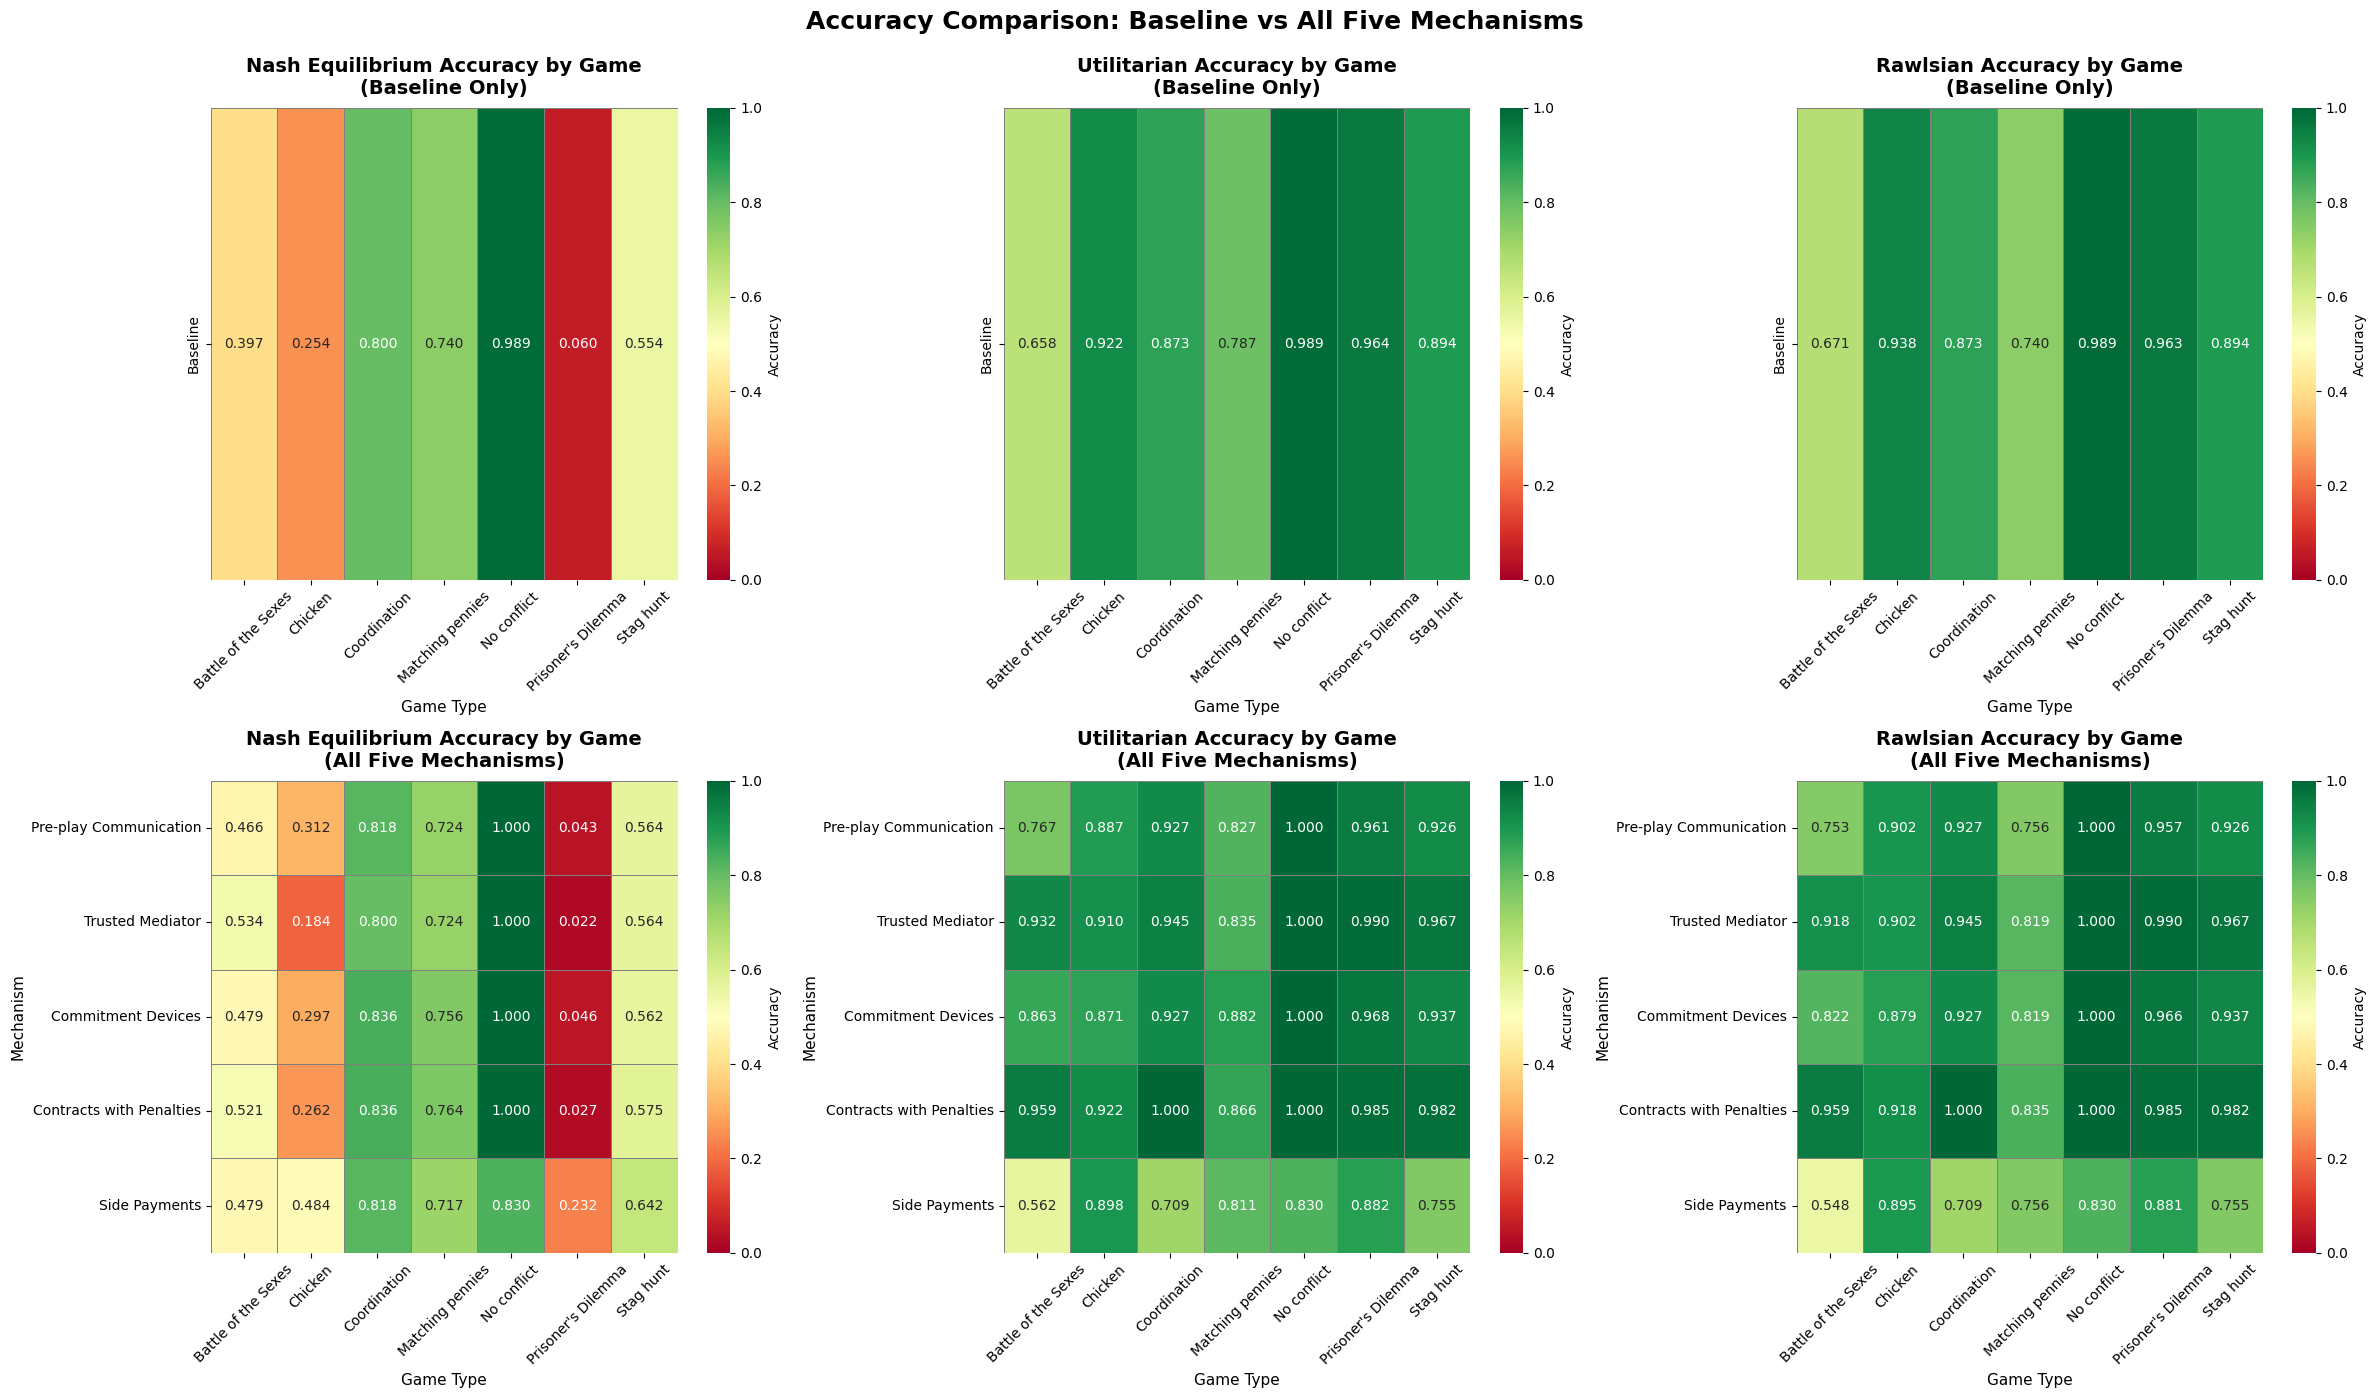


SUMMARY STATISTICS

Nash Equilibrium Accuracy:
Mechanism                          Mean      Std      Min      Max
------------------------------------------------------------
Baseline                          0.542    0.327    0.060    0.989
Pre-play Communication            0.561    0.323    0.043    1.000
Trusted Mediator                  0.547    0.344    0.022    1.000
Commitment Devices                0.568    0.329    0.046    1.000
Contracts with Penalties          0.569    0.338    0.027    1.000
Side Payments                     0.600    0.216    0.232    0.830

Utilitarian Accuracy:
Mechanism                          Mean      Std      Min      Max
------------------------------------------------------------
Baseline                          0.870    0.114    0.658    0.989
Pre-play Communication            0.899    0.080    0.767    1.000
Trusted Mediator                  0.940    0.056    0.835    1.000
Commitment Devices                0.921    0.052    0.863    1.000
Con

In [6]:
# Six Heatmaps - Baseline vs All Mechanisms by Game and Equilibrium Type

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Separate baseline from mechanisms
baseline_results = per_game_results['Baseline']
mechanism_names = [name for name in per_game_results.keys() if name != 'Baseline']
mechanism_results = {name: per_game_results[name] for name in mechanism_names}

# Get all unique games
all_games = sorted(baseline_results['game_name'].unique())

# Create figure with 6 subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('Accuracy Comparison: Baseline vs All Five Mechanisms',
            fontsize=18, fontweight='bold', y=0.995)

# Define equilibrium types
equilibrium_types = ['nash', 'utilitarian', 'rawlsian']
equilibrium_labels = ['Nash Equilibrium', 'Utilitarian', 'Rawlsian']

# ========== ROW 1: BASELINE ONLY ==========
for col, (eq_type, eq_label) in enumerate(zip(equilibrium_types, equilibrium_labels)):
    ax = axes[0, col]

    # Create matrix: 1 row (Baseline) x games
    matrix = np.zeros((1, len(all_games)))

    for j, game in enumerate(all_games):
        game_row = baseline_results[baseline_results['game_name'] == game]
        if len(game_row) > 0:
            matrix[0, j] = game_row[f'{eq_type}_accuracy'].values[0]
        else:
            matrix[0, j] = np.nan

    # Plot heatmap
    sns.heatmap(matrix,
                annot=True,
                fmt='.3f',
                cmap='RdYlGn',
                vmin=0,
                vmax=1,
                xticklabels=all_games,
                yticklabels=['Baseline'],
                cbar_kws={'label': 'Accuracy'},
                ax=ax,
                linewidths=0.5,
                linecolor='gray')

    ax.set_title(f'{eq_label} Accuracy by Game\n(Baseline Only)',
                fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Game Type', fontsize=11)
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)

# ========== ROW 2: ALL FIVE MECHANISMS ==========
for col, (eq_type, eq_label) in enumerate(zip(equilibrium_types, equilibrium_labels)):
    ax = axes[1, col]

    # Create matrix: 5 rows (mechanisms) x games
    matrix = np.zeros((len(mechanism_names), len(all_games)))

    for i, mechanism_name in enumerate(mechanism_names):
        results_df = mechanism_results[mechanism_name]
        for j, game in enumerate(all_games):
            game_row = results_df[results_df['game_name'] == game]
            if len(game_row) > 0:
                matrix[i, j] = game_row[f'{eq_type}_accuracy'].values[0]
            else:
                matrix[i, j] = np.nan

    # Plot heatmap
    sns.heatmap(matrix,
                annot=True,
                fmt='.3f',
                cmap='RdYlGn',
                vmin=0,
                vmax=1,
                xticklabels=all_games,
                yticklabels=mechanism_names,
                cbar_kws={'label': 'Accuracy'},
                ax=ax,
                linewidths=0.5,
                linecolor='gray')

    ax.set_title(f'{eq_label} Accuracy by Game\n(All Five Mechanisms)',
                fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Game Type', fontsize=11)
    ax.set_ylabel('Mechanism', fontsize=11)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('six_heatmaps_baseline_vs_mechanisms.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

for eq_type, eq_label in zip(equilibrium_types, equilibrium_labels):
    print(f"\n{eq_label} Accuracy:")
    print(f"{'Mechanism':<30s} {'Mean':>8s} {'Std':>8s} {'Min':>8s} {'Max':>8s}")
    print("-" * 60)

    # Baseline
    baseline_acc = baseline_results[f'{eq_type}_accuracy']
    print(f"{'Baseline':<30s} {baseline_acc.mean():8.3f} {baseline_acc.std():8.3f} "
        f"{baseline_acc.min():8.3f} {baseline_acc.max():8.3f}")

    # Mechanisms
    for mechanism_name in mechanism_names:
        results_df = mechanism_results[mechanism_name]
        acc = results_df[f'{eq_type}_accuracy']
        print(f"{mechanism_name:<30s} {acc.mean():8.3f} {acc.std():8.3f} "
            f"{acc.min():8.3f} {acc.max():8.3f}")

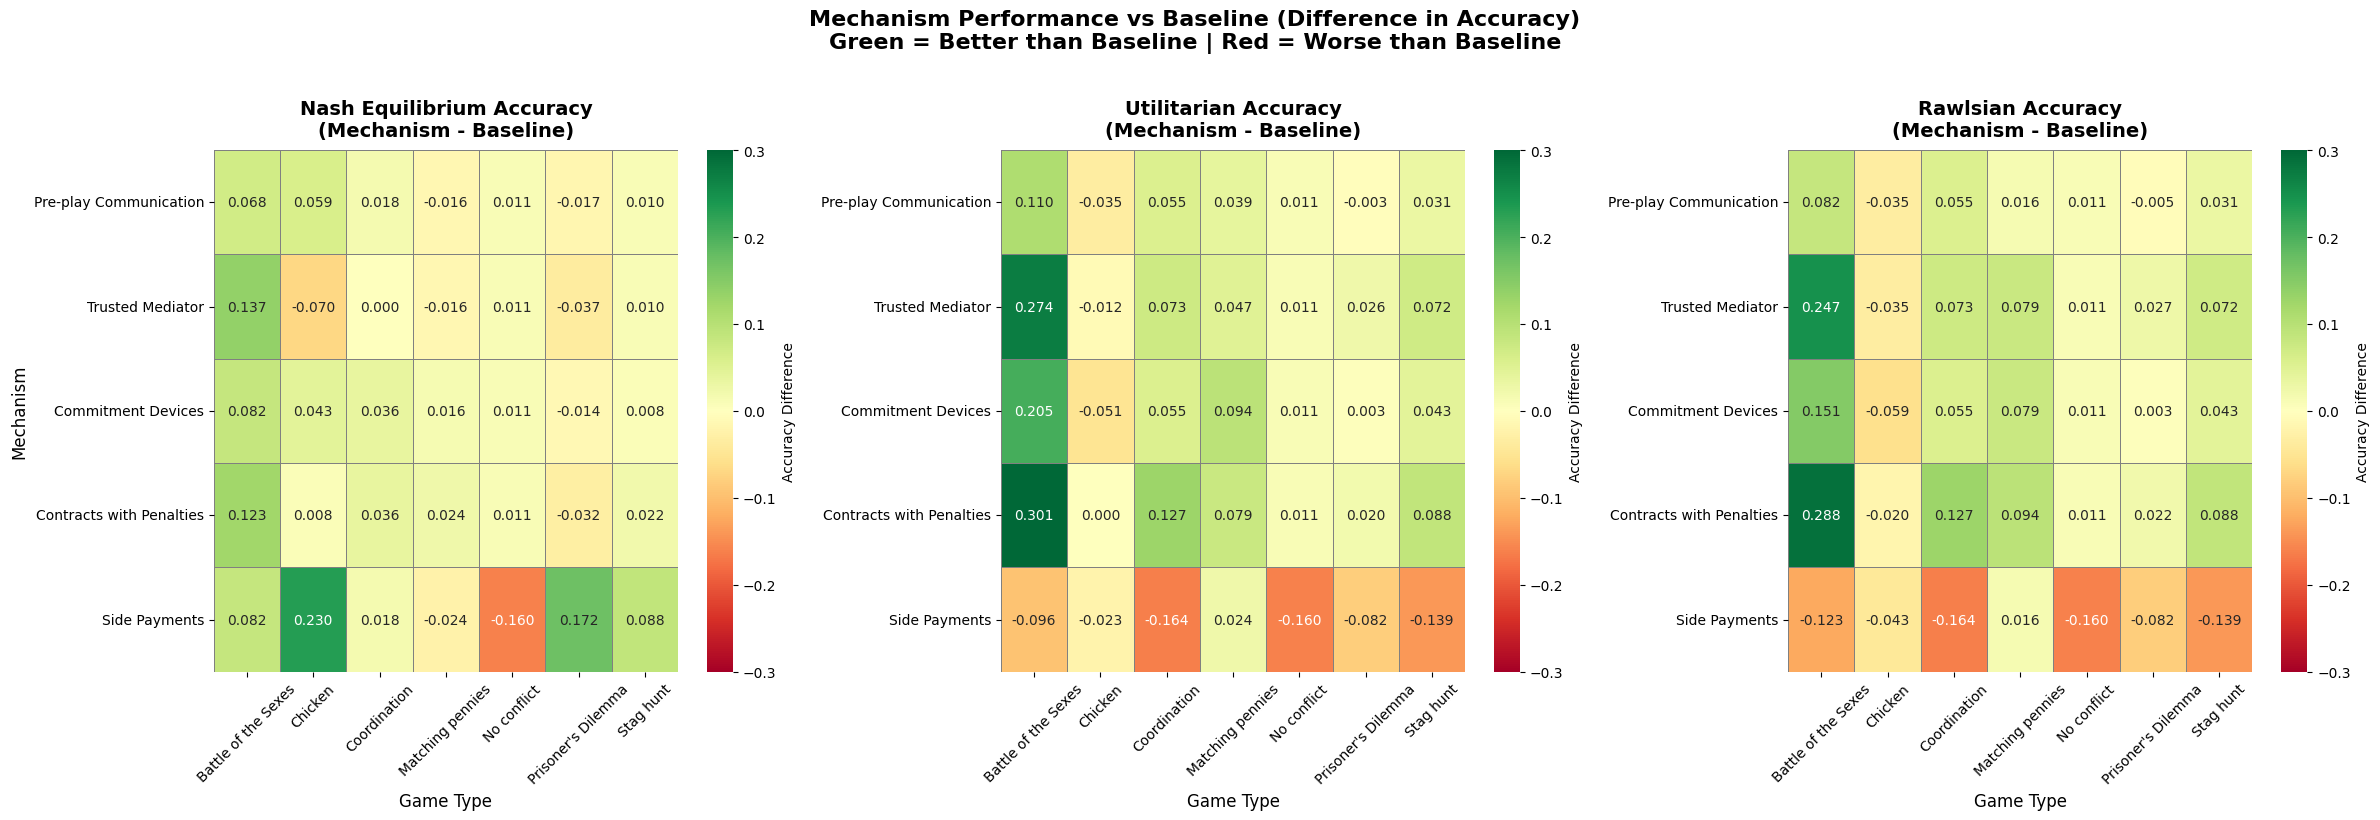


MECHANISM PERFORMANCE VS BASELINE (Δ Accuracy)

Nash Equilibrium:
Mechanism                          Mean Δ      Std Δ                 Best Game                Worst Game
----------------------------------------------------------------------------------------------------
Pre-play Communication              0.019      0.031 Battle of the Sexes (+0.068) Prisoner's Dilemma (-0.017)
Trusted Mediator                    0.005      0.060 Battle of the Sexes (+0.137)         Chicken (-0.070)
Commitment Devices                  0.026      0.029 Battle of the Sexes (+0.082) Prisoner's Dilemma (-0.014)
Contracts with Penalties            0.027      0.044 Battle of the Sexes (+0.123) Prisoner's Dilemma (-0.032)
Side Payments                       0.058      0.119         Chicken (+0.230)     No conflict (-0.160)

Utilitarian:
Mechanism                          Mean Δ      Std Δ                 Best Game                Worst Game
--------------------------------------------------------------------

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get baseline and mechanism results
baseline_results = per_game_results['Baseline']
mechanism_names = [name for name in per_game_results.keys() if name != 'Baseline']
all_games = sorted(baseline_results['game_name'].unique())

# Create figure with 3 heatmaps (one per equilibrium type)
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('Mechanism Performance vs Baseline (Difference in Accuracy)\nGreen = Better than Baseline | Red = Worse than Baseline',
            fontsize=16, fontweight='bold', y=1.02)

equilibrium_types = ['nash', 'utilitarian', 'rawlsian']
equilibrium_labels = ['Nash Equilibrium', 'Utilitarian', 'Rawlsian']

for col, (eq_type, eq_label) in enumerate(zip(equilibrium_types, equilibrium_labels)):
    ax = axes[col]

    # Create matrix: mechanisms x games (values = difference from baseline)
    diff_matrix = np.zeros((len(mechanism_names), len(all_games)))

    # Get baseline accuracies for each game
    baseline_by_game = {}
    for game in all_games:
        game_row = baseline_results[baseline_results['game_name'] == game]
        if len(game_row) > 0:
            baseline_by_game[game] = game_row[f'{eq_type}_accuracy'].values[0]
        else:
            baseline_by_game[game] = np.nan

    # Calculate differences for each mechanism
    for i, mechanism_name in enumerate(mechanism_names):
        results_df = per_game_results[mechanism_name]
        for j, game in enumerate(all_games):
            game_row = results_df[results_df['game_name'] == game]
            if len(game_row) > 0 and not np.isnan(baseline_by_game[game]):
                mechanism_acc = game_row[f'{eq_type}_accuracy'].values[0]
                diff_matrix[i, j] = mechanism_acc - baseline_by_game[game]
            else:
                diff_matrix[i, j] = np.nan

    # Plot heatmap with diverging colormap
    # Use RdYlGn: Red=worse, Yellow=neutral, Green=better
    sns.heatmap(diff_matrix,
                annot=True,
                fmt='.3f',
                cmap='RdYlGn',  # Diverging colormap
                center=0,  # Center at 0 (no change)
                vmin=-0.3,  # Adjust these based on your data range
                vmax=0.3,
                xticklabels=all_games,
                yticklabels=mechanism_names,
                cbar_kws={'label': 'Accuracy Difference'},
                ax=ax,
                linewidths=0.5,
                linecolor='gray')

    ax.set_title(f'{eq_label} Accuracy\n(Mechanism - Baseline)',
                fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Game Type', fontsize=12)
    ax.set_ylabel('Mechanism' if col == 0 else '', fontsize=12)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('mechanism_vs_baseline_differences.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print("\n" + "="*100)
print("MECHANISM PERFORMANCE VS BASELINE (Δ Accuracy)")
print("="*100)

for eq_type, eq_label in zip(equilibrium_types, equilibrium_labels):
    print(f"\n{eq_label}:")
    print(f"{'Mechanism':<30s} {'Mean Δ':>10s} {'Std Δ':>10s} {'Best Game':>25s} {'Worst Game':>25s}")
    print("-" * 100)

    # Get baseline accuracies
    baseline_by_game = {}
    for game in all_games:
        game_row = baseline_results[baseline_results['game_name'] == game]
        if len(game_row) > 0:
            baseline_by_game[game] = game_row[f'{eq_type}_accuracy'].values[0]

    # Calculate differences for each mechanism
    for mechanism_name in mechanism_names:
        results_df = per_game_results[mechanism_name]
        differences = []
        game_diffs = {}

        for game in all_games:
            game_row = results_df[results_df['game_name'] == game]
            if len(game_row) > 0 and game in baseline_by_game:
                mechanism_acc = game_row[f'{eq_type}_accuracy'].values[0]
                diff = mechanism_acc - baseline_by_game[game]
                differences.append(diff)
                game_diffs[game] = diff

        if differences:
            mean_diff = np.mean(differences)
            std_diff = np.std(differences)

            # Find best and worst games
            best_game = max(game_diffs, key=game_diffs.get)
            worst_game = min(game_diffs, key=game_diffs.get)
            best_diff = game_diffs[best_game]
            worst_diff = game_diffs[worst_game]

            print(f"{mechanism_name:<30s} {mean_diff:>10.3f} {std_diff:>10.3f} "
                f"{best_game:>15s} (+{best_diff:.3f}) "
                f"{worst_game:>15s} ({worst_diff:.3f})")

print("\n" + "="*100)
print("INTERPRETATION:")
print("  Positive values (green): Mechanism outperforms baseline")
print("  Negative values (red): Mechanism underperforms baseline")
print("  Zero (yellow): No difference from baseline")
print("="*100)